# 02-Identity & Access Management (IAM) Cryptography

In Lesson 01, we established the mathematical foundations of Cloud State $\mathbf{S}$ and automated infrastructure provisioning using Terraform and LocalStack. We verified that we can construct enterprise-grade infrastructure locally without incurring a single penny of cloud debt.

However, once infrastructure is provisioned, how do we securely control access to it? If any script can write to our data lake, malicious actors or buggy applications can corrupt our state. In the cloud, security is governed by **Identity & Access Management (IAM)**.

IAM is not merely a collection of usernames and passwords; it is a **cryptographic evaluation engine** that executes at microsecond scale. Every single API request sent to AWS (or LocalStack) is a cryptographically signed payload that must be mathematically evaluated against a set of JSON policies.

Let's boot our environment to engineer absolute zero-trust network boundaries.

In [3]:
# Required installations: pip install boto3 matplotlib seaborn
import boto3
import json
from botocore.exceptions import ClientError
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

print("✅ Cryptographic IAM Policy Evaluation Engine Initialized.")

✅ Cryptographic IAM Policy Evaluation Engine Initialized.


## Start LocalStack
```bash
docker run -d \
  --name localstack \
  -p 4566:4566 \
  localstack/localstack:3.8
```

# 1. The Mathematics of IAM Policy Evaluation

Every time an application makes an API call (e.g., trying to read an S3 object), the IAM engine treats the request as a tuple $\mathbf{R}$:


$$\mathbf{R} = \langle \text{Principal}, \text{Action}, \text{Resource}, \text{Context} \rangle$$

The engine gathers all applicable JSON policies and runs a deterministic evaluation algorithm to compute an outcome $A \in \{\text{Allow}, \text{Deny}\}$.

### The Evaluation Algorithm

1. **Default Deny:** By default, all requests are denied: $A_0 = \text{Deny}$.
2. **Explicit Deny Override:** The engine scans all statements. If any statement matches the tuple $\mathbf{R}$ and has an explicit `"Effect": "Deny"`, the evaluation terminates immediately:

$$\text{If } \exists \, s \in \text{Policies} \text{ such that } \text{Match}(s, \mathbf{R}) \land \text{Effect}(s) = \text{Deny} \implies A = \text{Deny}$$


3. **Explicit Allow:** If no explicit deny exists, the engine looks for an explicit `"Effect": "Allow"`. If found, the request is permitted:

$$\text{If } (\forall \, s, \neg\text{DenyMatch}(s, \mathbf{R})) \land (\exists \, s, \text{AllowMatch}(s, \mathbf{R})) \implies A = \text{Allow}$$


4. **Final Fallback:** If there are no matching allows, the default deny stands ($A = \text{Deny}$).

# 2. Imperative Execution: Crafting IAM Policies with Boto3

Let's use Python to programmatically enforce a zero-trust boundary. We will create an IAM Role for a machine learning worker and attach a strict, least-privilege JSON policy allowing it to only read data from our local landing zone.

We will execute this entirely against LocalStack to guarantee $0.00 cost.

In [4]:
# --- ⚙️ STEP 1: Initializing the AWS IAM Engine (LocalStack Vector) ---
print("--- 🚀 Initializing Boto3 IAM Provisioning (Local Network) ---")

boto3.setup_default_session(aws_access_key_id='test', aws_secret_access_key='test', region_name='us-east-1')
local_endpoint = 'http://localhost:4566'

iam_client = boto3.client('iam', endpoint_url=local_endpoint)

role_name = "Enterprise-ML-Worker-Role"
policy_name = "ReadOnly-DataLake-LandingZone"

# --- 📜 STEP 2: Defining the Cryptographic Trust & Access Policies ---
# The Trust Policy allows an EC2/Fargate instance to assume this role
trust_relationship_policy = {
    "Version": "2012-10-17",
    "Statement": [
        {
            "Effect": "Allow",
            "Principal": {"Service": "ecs-tasks.amazonaws.com"},
            "Action": "sts:AssumeRole"
        }
    ]
}

# The Access Policy defines the strict mathematical resource boundaries
data_access_policy = {
    "Version": "2012-10-17",
    "Statement": [
        {
            "Sid": "VisualDataLakeReadPerms",
            "Effect": "Allow",
            "Action": [
                "s3:GetObject",
                "s3:ListBucket"
            ],
            "Resource": [
                "arn:aws:s3:::local-enterprise-dl-landing-zone",
                "arn:aws:s3:::local-enterprise-dl-landing-zone/*"
            ]
        }
    ]
}

# --- 🛠️ STEP 3: Deploying to LocalStack ---
try:
    print(f"   [API CALL] Constructing IAM Role: {role_name}")
    role_response = iam_client.create_role(
        RoleName=role_name,
        AssumeRolePolicyDocument=json.dumps(trust_relationship_policy)
    )
    print("   ✅ IAM Role successfully injected into LocalStack environment.")
    
    print(f"\n   [API CALL] Attaching Access Policy to {role_name}...")
    iam_client.put_role_policy(
        RoleName=role_name,
        PolicyName=policy_name,
        PolicyDocument=json.dumps(data_access_policy)
    )
    print("   ✅ Access Boundary cryptographically bound to the role.")

except ClientError as e:
    if e.response['Error']['Code'] == 'EntityAlreadyExists':
        print(f"   ⚠️ [IDEMPOTENCY] IAM Entity already exists locally. Skipping.")
    else:
        raise e

--- 🚀 Initializing Boto3 IAM Provisioning (Local Network) ---
   [API CALL] Constructing IAM Role: Enterprise-ML-Worker-Role
   ✅ IAM Role successfully injected into LocalStack environment.

   [API CALL] Attaching Access Policy to Enterprise-ML-Worker-Role...
   ✅ Access Boundary cryptographically bound to the role.


# 3. Declarative Execution: Terraform IAM Boundaries

In enterprise cloud infrastructure, compiling JSON strings inside Python loops is an anti-pattern. Instead, we use Terraform to declaratively engineer security boundaries using the clean `aws_iam_policy_document` data source. This handles syntax validation at compilation time before hitting our infrastructure.

```hcl
# --- 📜 iam.tf (The Declarative IAM Configuration) ---

# 1. Compile the Trust Policy via the Terraform Graph
data "aws_iam_policy_document" "ecs_tasks_trust" {
  statement {
    actions = ["sts:AssumeRole"]
    effect  = "Allow"

    principals {
      type        = "Service"
      identifiers = ["ecs-tasks.amazonaws.com"]
    }
  }
}

# 2. Instantiate the Base IAM Role
resource "aws_iam_role" "ml_worker_role" {
  name               = "Enterprise-ML-Worker-Role"
  assume_role_policy = data.aws_iam_policy_document.ecs_tasks_trust.json
}

# 3. Compile the Cryptographic Access Boundary
data "aws_iam_policy_document" "datalake_read_access" {
  statement {
    sid    = "VisualDataLakeReadPerms"
    effect = "Allow"
    
    actions = [
      "s3:GetObject",
      "s3:ListBucket"
    ]

    resources = [
      "arn:aws:s3:::local-enterprise-dl-landing-zone",
      "arn:aws:s3:::local-enterprise-dl-landing-zone/*"
    ]
  }
}

# 4. Bind the Policy directly to the Role
resource "aws_iam_role_policy" "ml_worker_policy_binding" {
  name   = "ReadOnly-DataLake-LandingZone"
  role   = aws_iam_role.ml_worker_role.id
  policy = data.aws_iam_policy_document.datalake_read_access.json
}

```


# 4. Visualizing Cryptographic Policy Boundaries

To understand how the IAM evaluation engine sits invisibly between computational workers and physical state resources, let's map out the evaluation flow under local sandboxing.

/tmp/ipykernel_2520/977785324.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((5.0, 1.5), 4.0, 5.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=2))
/tmp/ipykernel_2520/977785324.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((5.5, 4.5), 3.0, 0.8, fill=True, color='#2c3e50', edgecolor='black'))
/tmp/ipykernel_2520/977785324.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((5.5, 3.2), 3.0, 0.8, fill=True, color='#2c3e50', edgecolor='black'))
/tmp/ipykernel_2520/977785324.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((5.5, 1.9), 3.0, 0.8, fill=True, color='#2c3e50', edgecolor='black'))


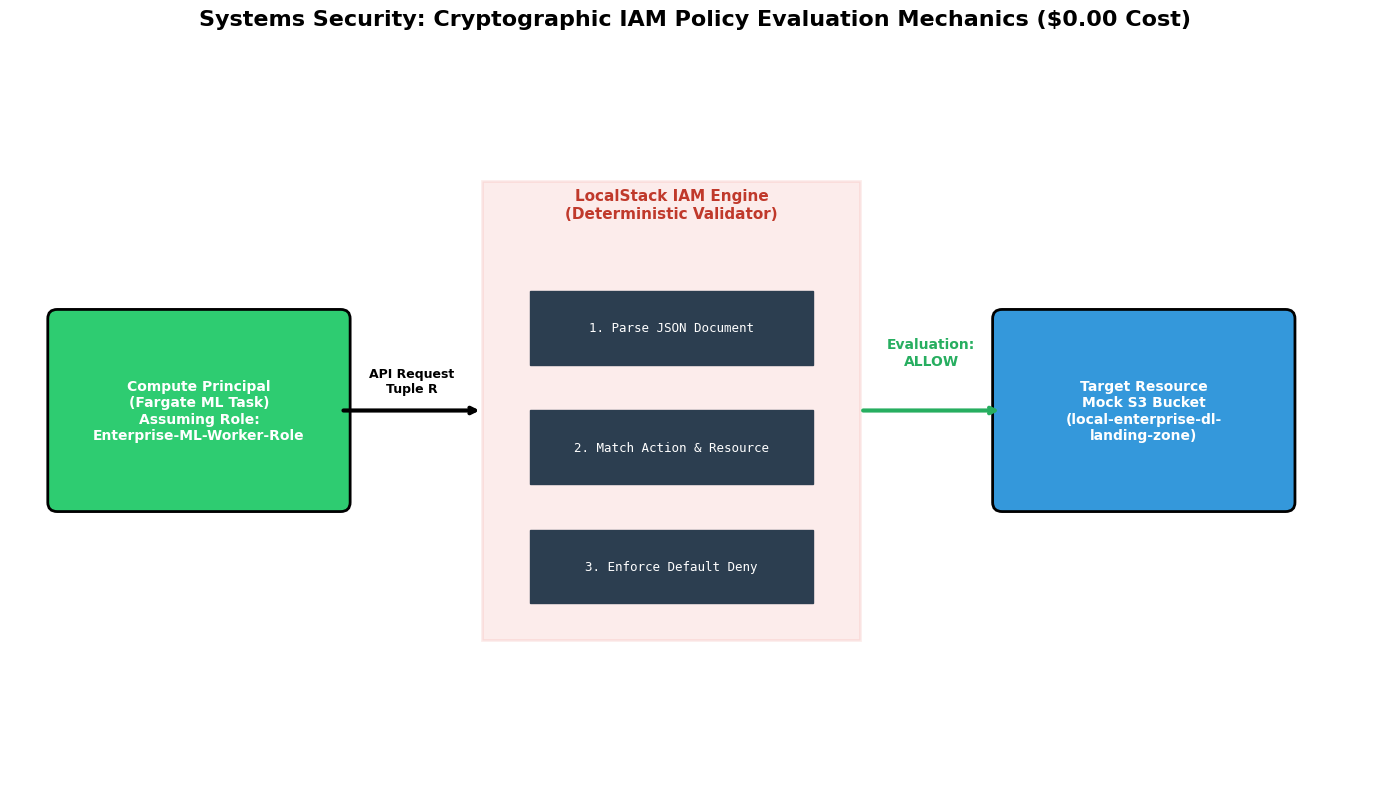

In [5]:
# Visualizing IAM Cryptographic Policy Evaluation
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Security: Cryptographic IAM Policy Evaluation Mechanics ($0.00 Cost)", fontsize=16, fontweight='bold')

ax.axis('off')

# --- LEFT: THE COMPUTE PRINCIPAL ---
ax.add_patch(patches.FancyBboxPatch((0.5, 3.0), 3.0, 2.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2ecc71'))
ax.text(2.0, 4.0, "Compute Principal\n(Fargate ML Task)\nAssuming Role:\nEnterprise-ML-Worker-Role", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# --- MIDDLE: THE CRYTOGRAPHIC EVALUATION ENGINE ---
ax.add_patch(patches.Rectangle((5.0, 1.5), 4.0, 5.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=2))
ax.text(7.0, 6.1, "LocalStack IAM Engine\n(Deterministic Validator)", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

# Check steps
ax.add_patch(patches.Rectangle((5.5, 4.5), 3.0, 0.8, fill=True, color='#2c3e50', edgecolor='black'))
ax.text(7.0, 4.9, "1. Parse JSON Document", ha='center', va='center', color='white', fontsize=9, fontfamily='monospace')

ax.add_patch(patches.Rectangle((5.5, 3.2), 3.0, 0.8, fill=True, color='#2c3e50', edgecolor='black'))
ax.text(7.0, 3.6, "2. Match Action & Resource", ha='center', va='center', color='white', fontsize=9, fontfamily='monospace')

ax.add_patch(patches.Rectangle((5.5, 1.9), 3.0, 0.8, fill=True, color='#2c3e50', edgecolor='black'))
ax.text(7.0, 2.3, "3. Enforce Default Deny", ha='center', va='center', color='white', fontsize=9, fontfamily='monospace')

# --- RIGHT: THE PROTECTED SOURCE ---
ax.add_patch(patches.FancyBboxPatch((10.5, 3.0), 3.0, 2.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#3498db'))
ax.text(12.0, 4.0, "Target Resource\nMock S3 Bucket\n(local-enterprise-dl-\nlanding-zone)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# --- ROUTING LINES ---
# Request Arrow
ax.annotate("", xy=(5.0, 4.0), xytext=(3.5, 4.0), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.text(4.25, 4.2, "API Request\nTuple R", ha='center', fontsize=9, fontweight='bold')

# Authorization Success Arrow
ax.annotate("", xy=(10.5, 4.0), xytext=(9.0, 4.0), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
ax.text(9.75, 4.5, "Evaluation:\nALLOW", ha='center', color='#27ae60', fontweight='bold', fontsize=10)

plt.xlim(0, 14.5)
plt.ylim(0, 8)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of an IAM Policy like a **Digital Security Badge inside a Highly Restricted Government Facility**:

* **The Principal (The Worker):** You are a contractor hired to analyze environmental soil samples inside Lab A.
* **The API Request:** You walk up to the electronic door handle of Lab A and swipe your badge. You are asking the building system: *"Can I open this door (Action: `s3:GetObject`) to access this physical room (Resource: `arn:aws:s3:::Lab-A`)?"*
* **The Default Deny:** If you do not have a badge, or if your badge hasn't been explicitly programmed yet, the door stays locked. The building assumes you are an intruder.
* **The Explicit Policy:** The security administrator programs your badge with a strict code: *Allow this person to Enter Lab A, but do not allow them to enter Lab B, and explicitly Deny them from accessing the weapons locker.* * **The Evaluation:** The second you swipe your badge, the electronic door controller runs a local evaluation logic check. It verifies your ID, checks if your access list allows Lab A, ensures there is no restriction code blocking you today, and clicks the door open.

By utilizing IAM roles mapped directly onto our serverless infrastructure configurations, we guarantee that even if a hacker compromises an application, they cannot pivot to access any data outside the strict boundaries explicitly written in the policy blueprint.